# Tugas 2 Pengenalan Pola - Klasifikasi Signal 1D

## Evan Razzan Adytaputra			(24/545257/PA/23166)
## Muhammad Rayyan Buna Satria 	(24/543564/PA/23096)

# a) Membaca input audio & preprocessing

Membaca dataset audio perempuan dan laki-laki lalu normalisasi sample rate menjadi 16.000 Hz dan bentuk sinyal menjadi mono agar seluruh dataset memiliki format yang seragam.

In [ ]:
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import zipfile
import os
from google.colab import files
from pathlib import Path
import shutil

!pip install librosa
if not os.path.exists("/content/Tuga-Pengenalan-Pola-Klasifikasi-Signal-1D"):
    !git clone https://github.com/evanrazzanadytaputra2006-dotcom/Tuga-Pengenalan-Pola-Klasifikasi-Signal-1D

#ekstraksi isi folder
base = "/content/Tuga-Pengenalan-Pola-Klasifikasi-Signal-1D"
female_zip = os.path.join(base, "female_audio.zip")
male_zip = os.path.join(base, "male_audio.zip")

female_dir = os.path.join(base, "female")
male_dir = os.path.join(base, "male")

#hapus folder lama jika masih ada
if os.path.exists(female_dir):
    shutil.rmtree(female_dir)

if os.path.exists(male_dir):
    shutil.rmtree(male_dir)

os.makedirs(female_dir, exist_ok=True)
os.makedirs(male_dir, exist_ok=True)

with zipfile.ZipFile(female_zip, 'r') as zip_ref:
    zip_ref.extractall(female_dir)

with zipfile.ZipFile(male_zip, 'r') as zip_ref:
    zip_ref.extractall(male_dir)


#rename file agar lebih terorganisir
def rename_audio_files(folder, prefix):
    folder = Path(folder)
    audio_files = sorted(folder.rglob("*.mp3"))

    for i, old_path in enumerate(audio_files, start=1):
        new_path = folder / f"{prefix}{i}.mp3"
        old_path.rename(new_path)

    print(f"Renamed {len(audio_files)} files.")

rename_audio_files(female_dir, "female")
rename_audio_files(male_dir, "male")

female_files = sorted(
    Path(female_dir).glob("female*.mp3"),
    key=lambda x: int(x.stem.replace("female", ""))
)

male_files = sorted(
    Path(male_dir).glob("male*.mp3"),
    key=lambda x: int(x.stem.replace("male", ""))
)

print(female_files[:5])
print(len(female_files))
print(male_files[:5])
print(len(male_files))

Renamed 65 files.
Renamed 65 files.
[PosixPath('/content/Tuga-Pengenalan-Pola-Klasifikasi-Signal-1D/female/female1.mp3'), PosixPath('/content/Tuga-Pengenalan-Pola-Klasifikasi-Signal-1D/female/female2.mp3'), PosixPath('/content/Tuga-Pengenalan-Pola-Klasifikasi-Signal-1D/female/female3.mp3'), PosixPath('/content/Tuga-Pengenalan-Pola-Klasifikasi-Signal-1D/female/female4.mp3'), PosixPath('/content/Tuga-Pengenalan-Pola-Klasifikasi-Signal-1D/female/female5.mp3')]
65
[PosixPath('/content/Tuga-Pengenalan-Pola-Klasifikasi-Signal-1D/male/male1.mp3'), PosixPath('/content/Tuga-Pengenalan-Pola-Klasifikasi-Signal-1D/male/male2.mp3'), PosixPath('/content/Tuga-Pengenalan-Pola-Klasifikasi-Signal-1D/male/male3.mp3'), PosixPath('/content/Tuga-Pengenalan-Pola-Klasifikasi-Signal-1D/male/male4.mp3'), PosixPath('/content/Tuga-Pengenalan-Pola-Klasifikasi-Signal-1D/male/male5.mp3')]
65


File: /content/Tuga-Pengenalan-Pola-Klasifikasi-Signal-1D/female/female1.mp3
Sample rate: 24000
Jumlah samples: 157824
Durasi: 6.576 seconds


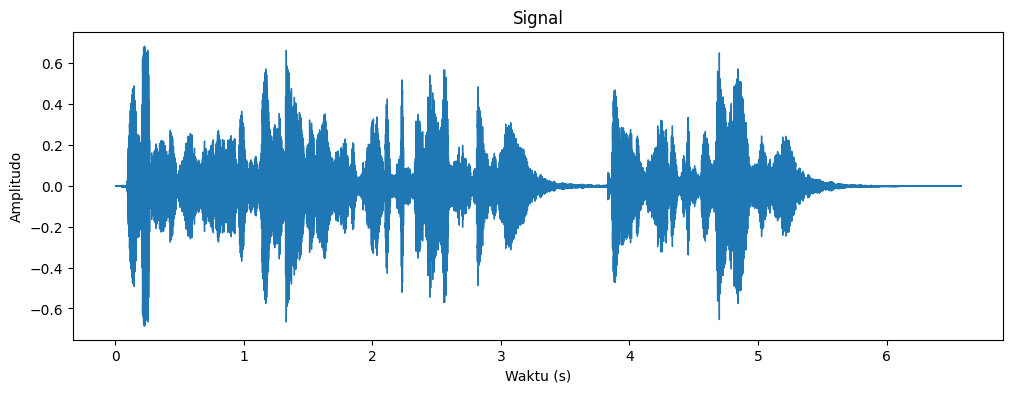

In [ ]:
female_file = female_files[0]

signal, sr = librosa.load(female_file, sr=None)

print("File:", female_file)
print("Sample rate:", sr)
print("Jumlah samples:", len(signal))
print("Durasi:", len(signal) / sr, "seconds")

plt.figure(figsize=(12, 4))

librosa.display.waveshow(signal, sr=sr)

plt.title("Signal")
plt.xlabel("Waktu (s)")
plt.ylabel("Amplitudo")
plt.show()

In [ ]:
def get_audio_info(files):
    info = []

    for file in files:
        signal, sr = librosa.load(file, sr=None)

        info.append({
            "file": file.name,
            "sample_rate": sr,
            "samples": len(signal),
            "duration": len(signal) / sr
        })

    return pd.DataFrame(info)

female_info = get_audio_info(female_files)
male_info = get_audio_info(male_files)

print("Female:")
display(female_info)

print("Male:")
display(male_info)

Female:


,file,sample_rate,samples,duration
0,female1.mp3,24000,157824,6.576000
1,female2.mp3,48000,179712,3.744000
2,female3.mp3,24000,50688,2.112000
3,female4.mp3,48000,79488,1.656000
4,female5.mp3,24000,36864,1.536000
...,...,...,...,...
60,female61.mp3,44100,142848,3.239184
61,female62.mp3,24000,28224,1.176000
62,female63.mp3,44100,59904,1.358367
63,female64.mp3,48000,266240,5.546667


Male:


,file,sample_rate,samples,duration
0,male1.mp3,24000,440640,18.360000
1,male2.mp3,48000,749952,15.624000
2,male3.mp3,44100,244224,5.537959
3,male4.mp3,48000,179712,3.744000
4,male5.mp3,48000,141696,2.952000
...,...,...,...,...
60,male61.mp3,44100,78336,1.776327
61,male62.mp3,24000,23040,0.960000
62,male63.mp3,24000,116352,4.848000
63,male64.mp3,44100,127872,2.899592


# B) Ekstraksi Fitur

Fitur yang akan diekstraksi adalah Fitur domain waktu (RMS dan ZCR), Firut domain frekuensi (Spectral centroid, spectral bandwidth, dan spectral rolloff), pitch, dan MFCC.

In [ ]:
def extract_features(file_path):
    signal, sr = librosa.load(
        file_path,
        sr=16000,
        mono=True
    )

    features = {}

    #Fitur domain waktu
    rms = librosa.feature.rms(y=signal) #energi RMS
    features["rms_mean"] = np.mean(rms)
    features["rms_std"] = np.std(rms)

    zcr = librosa.feature.zero_crossing_rate(signal) #Zero crossing rate
    features["zcr_mean"] = np.mean(zcr)
    features["zcr_std"] = np.std(zcr)


    #Fitur domain frekuensi
    centroid = librosa.feature.spectral_centroid( #spectral centroid
        y=signal,
        sr=sr
    )

    features["spectral_centroid_mean"] = np.mean(centroid)
    features["spectral_centroid_std"] = np.std(centroid)


    bandwidth = librosa.feature.spectral_bandwidth( #spectral bandwidth
        y=signal,
        sr=sr
    )
    features["spectral_bandwidth_mean"] = np.mean(bandwidth)
    features["spectral_bandwidth_std"] = np.std(bandwidth)


    rolloff = librosa.feature.spectral_rolloff( #spectral rolloff
        y=signal,
        sr=sr
    )
    features["spectral_rolloff_mean"] = np.mean(rolloff)
    features["spectral_rolloff_std"] = np.std(rolloff)


    #memproses pitch
    f0, voiced_flag, voiced_prob = librosa.pyin(
        signal,
        fmin=librosa.note_to_hz("C2"),
        fmax=librosa.note_to_hz("C7"),
        sr=sr
    )

    #Menghapus data kosong
    f0_valid = f0[~np.isnan(f0)]

    if len(f0_valid) > 0:
        features["pitch_mean"] = np.mean(f0_valid)
        features["pitch_std"] = np.std(f0_valid)
    else:
        features["pitch_mean"] = 0
        features["pitch_std"] = 0


    #MFCC
    mfcc = librosa.feature.mfcc(
        y=signal,
        sr=sr,
        n_mfcc=13
    )

    for i in range(13):
        features[f"mfcc{i+1}_mean"] = np.mean(mfcc[i])
        features[f"mfcc{i+1}_std"] = np.std(mfcc[i])


    return features

In [ ]:
#ekstrak fitur dari tiap instansi male dan female lalu masukan ke listnya masing-masing
male_d = []
for file in male_files:
    features = extract_features(file)
    features["file"] = file.name
    features["gender"] = "male"
    male_d.append(features)

female_d = []
for file in female_files:
    features = extract_features(file)
    features["file"] = file.name
    features["gender"] = "female"
    female_d.append(features)

a = male_d + female_d
df = pd.DataFrame(a)

In [ ]:
display(df.iloc[0:5])

display(df.iloc[64:70])

,rms_mean,rms_std,zcr_mean,zcr_std,spectral_centroid_mean,spectral_centroid_std,spectral_bandwidth_mean,spectral_bandwidth_std,spectral_rolloff_mean,spectral_rolloff_std,...,mfcc10_mean,mfcc10_std,mfcc11_mean,mfcc11_std,mfcc12_mean,mfcc12_std,mfcc13_mean,mfcc13_std,file,gender
0,0.138828,0.035533,0.060750,0.055207,1226.753505,799.789746,1619.148760,567.217599,2643.251851,1852.153638,...,-0.354680,11.509374,1.164309,7.994808,3.590283,8.777190,-1.571168,7.902064,male1.mp3,male
1,0.015528,0.038169,0.261173,0.099968,2346.792636,593.481328,1807.641887,501.593044,4474.229934,1401.147726,...,-7.808680,11.375743,1.029183,6.793565,-2.670336,6.900439,-4.804971,8.717589,male2.mp3,male
2,0.022594,0.044351,0.251114,0.094171,2424.866088,625.293504,1790.899405,140.998843,4392.420977,1071.372651,...,-2.187791,9.367225,-3.999664,6.409571,-0.087703,6.023243,-4.083819,6.003952,male3.mp3,male
3,0.035214,0.042852,0.110985,0.066852,1762.254352,604.542866,1794.273780,310.941604,3422.272246,1301.303687,...,2.712421,8.520287,-7.539059,11.817324,2.210930,9.627531,-2.587926,8.179892,male4.mp3,male
4,0.138841,0.044529,0.157074,0.143543,2160.694356,1316.406694,1938.255857,420.899077,4233.702957,1926.354729,...,-6.465609,13.334142,-5.370240,11.631182,0.436072,10.719502,-1.881313,13.449205,male5.mp3,male


,rms_mean,rms_std,zcr_mean,zcr_std,spectral_centroid_mean,spectral_centroid_std,spectral_bandwidth_mean,spectral_bandwidth_std,spectral_rolloff_mean,spectral_rolloff_std,...,mfcc10_mean,mfcc10_std,mfcc11_mean,mfcc11_std,mfcc12_mean,mfcc12_std,mfcc13_mean,mfcc13_std,file,gender
64,0.017382,0.023981,0.248340,0.297890,2333.362384,1899.895576,1765.322968,419.038093,3830.245536,2433.863947,...,8.285759,12.020097,-2.211484,13.232225,2.995748,7.241183,1.765711,9.333780,male65.mp3,male
65,0.075272,0.059211,0.143431,0.151534,1912.666800,1284.217523,1747.920776,516.767047,3601.752124,2018.819238,...,-11.554960,8.744193,-5.854064,8.874886,-8.195252,9.018716,-4.127706,6.584419,female1.mp3,female
66,0.110361,0.080262,0.209626,0.078657,2118.496062,554.248969,1583.383479,345.324329,3996.557203,882.661641,...,-20.645115,20.250261,8.998469,14.308263,-22.347586,17.621197,-0.835976,15.271281,female2.mp3,female
67,0.010628,0.011827,0.098589,0.056097,1380.756676,727.940223,1407.001891,588.175933,2812.616604,1595.377341,...,-7.180996,10.743756,-6.218463,9.268476,-4.377144,9.736710,0.906824,5.473448,female3.mp3,female
68,0.166062,0.128682,0.359741,0.143646,3401.122780,1083.348138,1728.028361,419.650110,5149.789663,1282.126153,...,15.963472,28.589655,7.060376,27.245073,-2.885093,21.282681,-4.258298,30.203249,female4.mp3,female
69,0.033785,0.022558,0.116560,0.043834,1795.293156,289.873881,1613.526401,336.472713,3570.631378,722.054155,...,-1.408207,7.607053,-3.409562,12.254799,-11.106988,13.588893,6.888251,11.175037,female5.mp3,female


In [ ]:
#binary encoding (male = 0, female = 1)
for i in range(len(df)):
  if df.loc[i, "gender"] == "male":
    df.loc[i, "gender"] = 0
  else:
    df.loc[i, "gender"] = 1

display(df.head())
display(df.iloc[64:70])

,rms_mean,rms_std,zcr_mean,zcr_std,spectral_centroid_mean,spectral_centroid_std,spectral_bandwidth_mean,spectral_bandwidth_std,spectral_rolloff_mean,spectral_rolloff_std,...,mfcc10_mean,mfcc10_std,mfcc11_mean,mfcc11_std,mfcc12_mean,mfcc12_std,mfcc13_mean,mfcc13_std,file,gender
0,0.138828,0.035533,0.060750,0.055207,1226.753505,799.789746,1619.148760,567.217599,2643.251851,1852.153638,...,-0.354680,11.509374,1.164309,7.994808,3.590283,8.777190,-1.571168,7.902064,male1.mp3,0
1,0.015528,0.038169,0.261173,0.099968,2346.792636,593.481328,1807.641887,501.593044,4474.229934,1401.147726,...,-7.808680,11.375743,1.029183,6.793565,-2.670336,6.900439,-4.804971,8.717589,male2.mp3,0
2,0.022594,0.044351,0.251114,0.094171,2424.866088,625.293504,1790.899405,140.998843,4392.420977,1071.372651,...,-2.187791,9.367225,-3.999664,6.409571,-0.087703,6.023243,-4.083819,6.003952,male3.mp3,0
3,0.035214,0.042852,0.110985,0.066852,1762.254352,604.542866,1794.273780,310.941604,3422.272246,1301.303687,...,2.712421,8.520287,-7.539059,11.817324,2.210930,9.627531,-2.587926,8.179892,male4.mp3,0
4,0.138841,0.044529,0.157074,0.143543,2160.694356,1316.406694,1938.255857,420.899077,4233.702957,1926.354729,...,-6.465609,13.334142,-5.370240,11.631182,0.436072,10.719502,-1.881313,13.449205,male5.mp3,0


,rms_mean,rms_std,zcr_mean,zcr_std,spectral_centroid_mean,spectral_centroid_std,spectral_bandwidth_mean,spectral_bandwidth_std,spectral_rolloff_mean,spectral_rolloff_std,...,mfcc10_mean,mfcc10_std,mfcc11_mean,mfcc11_std,mfcc12_mean,mfcc12_std,mfcc13_mean,mfcc13_std,file,gender
64,0.017382,0.023981,0.248340,0.297890,2333.362384,1899.895576,1765.322968,419.038093,3830.245536,2433.863947,...,8.285759,12.020097,-2.211484,13.232225,2.995748,7.241183,1.765711,9.333780,male65.mp3,0
65,0.075272,0.059211,0.143431,0.151534,1912.666800,1284.217523,1747.920776,516.767047,3601.752124,2018.819238,...,-11.554960,8.744193,-5.854064,8.874886,-8.195252,9.018716,-4.127706,6.584419,female1.mp3,1
66,0.110361,0.080262,0.209626,0.078657,2118.496062,554.248969,1583.383479,345.324329,3996.557203,882.661641,...,-20.645115,20.250261,8.998469,14.308263,-22.347586,17.621197,-0.835976,15.271281,female2.mp3,1
67,0.010628,0.011827,0.098589,0.056097,1380.756676,727.940223,1407.001891,588.175933,2812.616604,1595.377341,...,-7.180996,10.743756,-6.218463,9.268476,-4.377144,9.736710,0.906824,5.473448,female3.mp3,1
68,0.166062,0.128682,0.359741,0.143646,3401.122780,1083.348138,1728.028361,419.650110,5149.789663,1282.126153,...,15.963472,28.589655,7.060376,27.245073,-2.885093,21.282681,-4.258298,30.203249,female4.mp3,1
69,0.033785,0.022558,0.116560,0.043834,1795.293156,289.873881,1613.526401,336.472713,3570.631378,722.054155,...,-1.408207,7.607053,-3.409562,12.254799,-11.106988,13.588893,6.888251,11.175037,female5.mp3,1


# C) Model Selection & Cross Validation

Melatih berbagai model menggunakan fitur-fitur audio yang telah diekstraksi dan mengambil model dengan F1-score rata-rata tertinggi setelah 5-fold cross validation.

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import numpy as np
import pandas as pd

# Memisahkan fitur dan target
# Kolom 'file' dan 'gender' dikeluarkan dari fitur (gender adalah target 'y')
X = df.drop(columns=["file", "gender"])
y = df["gender"].astype(int)

# Train-test split (85% train, 15% test)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    stratify=y,
    random_state=42
)

# Daftar model yang akan diuji
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "Naive Bayes": Pipeline([
        ("scaler", StandardScaler()),
        ("model", GaussianNB())
    ]),
    "kNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=5))
    ]),
    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel='rbf', random_state=42))
    ]),
    "Decision Tree": Pipeline([
        ("model", DecisionTreeClassifier(random_state=42))
    ]),
    "Random Forest": Pipeline([
        ("model", RandomForestClassifier(n_estimators=100, random_state=42))
    ]),
    "XGBoost": Pipeline([
        ("model", XGBClassifier(eval_metric='logloss', random_state=42))
    ])
}

# Evaluasi model menggunakan Cross Validation (F1-score)
best_mean_score = 0
best_model_name = ""

for name, model in models.items():
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring='f1'
    )
    mean_score = scores.mean()
    print(f"=== {name} ===")
    print(f"Scores: {scores}")
    print(f"Mean F1: {mean_score:.4f}\n")

    if mean_score > best_mean_score:
        best_mean_score = mean_score
        best_model_name = name

print(f"Model terbaik berdasarkan CV F1-score: {best_model_name} ({best_mean_score:.4f})")

=== Logistic Regression ===
Scores: [0.8        0.95238095 0.52631579 0.76190476 0.86956522]
Mean F1: 0.7820

=== Naive Bayes ===
Scores: [0.81818182 0.84210526 0.66666667 0.7826087  0.76190476]
Mean F1: 0.7743

=== kNN ===
Scores: [0.81818182 0.90909091 0.60869565 0.85714286 0.90909091]
Mean F1: 0.8204

=== SVM ===
Scores: [0.7826087  0.85714286 0.6        0.95652174 0.7826087 ]
Mean F1: 0.7958

=== Decision Tree ===
Scores: [0.72727273 0.72727273 0.72727273 0.81481481 0.58823529]
Mean F1: 0.7170

=== Random Forest ===
Scores: [0.7        0.9        0.57142857 0.88       0.90909091]
Mean F1: 0.7921

=== XGBoost ===
Scores: [0.7        0.8        0.60869565 0.84615385 0.81818182]
Mean F1: 0.7546

Model terbaik berdasarkan CV F1-score: kNN (0.8204)


#D) Hyperparameter Tuning untuk Model Terbaik

Kita akan melakukan pencarian hyperparameter optimal menggunakan `GridSearchCV` berdasarkan model terbaik yang terpilih di atas.

In [ ]:
# Tentukan parameter grid berdasarkan model terbaik
if best_model_name == "kNN":
    param_grid = {
        'model__n_neighbors': [3, 5, 7, 9, 11, 15],
        'model__weights': ['uniform', 'distance'],
        'model__metric': ['euclidean', 'manhattan', 'minkowski']
    }
    base_model = models["kNN"]
elif best_model_name == "Random Forest":
    param_grid = {
        'model__n_estimators': [50, 100, 200],
        'model__max_depth': [None, 10, 20],
        'model__min_samples_split': [2, 5, 10]
    }
    base_model = models["Random Forest"]
elif best_model_name == "SVM":
    param_grid = {
        'model__C': [0.1, 1, 10, 100],
        'model__gamma': ['scale', 'auto', 0.01, 0.1]
    }
    base_model = models["SVM"]
elif best_model_name == "XGBoost":
    param_grid = {
        'model__n_estimators': [50, 100, 200],
        'model__learning_rate': [0.01, 0.1, 0.2],
        'model__max_depth': [3, 5, 7]
    }
    base_model = models["XGBoost"]
elif best_model_name == "Logistic Regression":
    param_grid = {
        'model__C': [0.01, 0.1, 1, 10, 100]
    }
    base_model = models["Logistic Regression"]
else:
    param_grid = {}
    base_model = models[best_model_name]

if param_grid:
    print(f"Melakukan Tuning Hyperparameter untuk {best_model_name}...")
    grid_search = GridSearchCV(
        base_model,
        param_grid,
        cv=5,
        scoring='f1',
        n_jobs=-1
    )
    grid_search.fit(X_train, y_train)

    print("Best Parameters:", grid_search.best_params_)
    best_estimator = grid_search.best_estimator_
else:
    print(f"Menggunakan model default {best_model_name} (tidak ada grid tuning khusus).")
    best_estimator = base_model.fit(X_train, y_train)

# Evaluasi pada Test Set
y_pred = best_estimator.predict(X_test)
print("\n=== Evaluasi Akhir pada Test Set ===")
print(classification_report(y_test, y_pred, target_names=['Male', 'Female']))

Melakukan Tuning Hyperparameter untuk kNN...
Best Parameters: {'model__metric': 'manhattan', 'model__n_neighbors': 11, 'model__weights': 'uniform'}

=== Evaluasi Akhir pada Test Set ===
              precision    recall  f1-score   support

        Male       0.78      0.70      0.74        10
      Female       0.73      0.80      0.76        10

    accuracy                           0.75        20
   macro avg       0.75      0.75      0.75        20
weighted avg       0.75      0.75      0.75        20




# E) Visualisasi Hasil Training & Testing

Untuk mempermudah analisis performa model kNN terbaik hasil tuning, kita akan memvisualisasikan Confusion Matrix serta membandingkan performa model pada data training (melalui rata-rata Cross-Validation) dan data testing (Test Set).


=== MENAMPILKAN PLOT UNTUK BAGIAN TRAINING ===


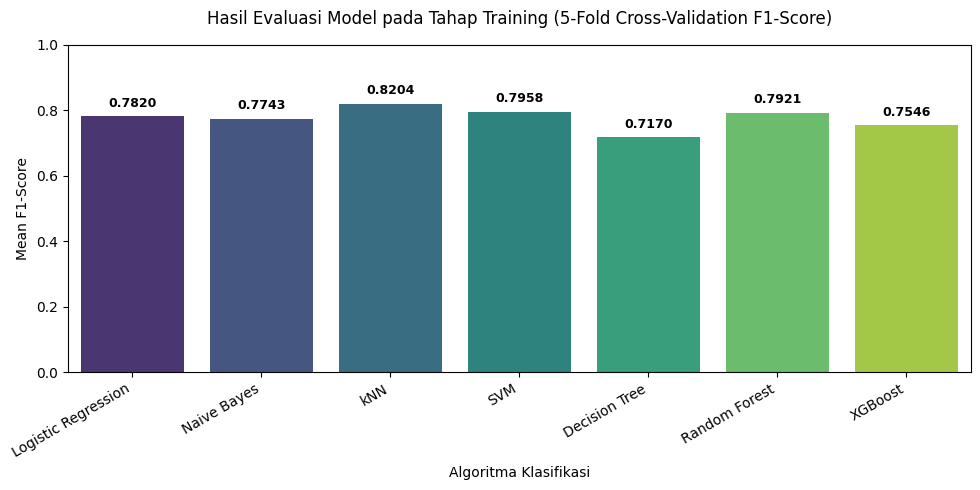


=== MENAMPILKAN PLOT UNTUK BAGIAN TESTING ===


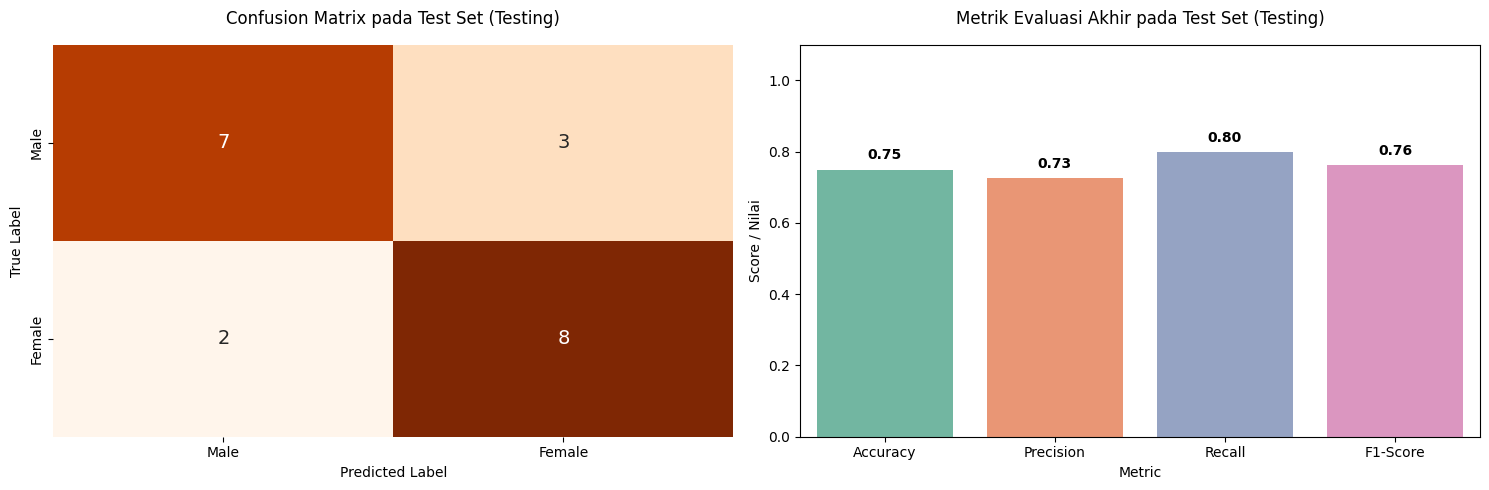

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# --- 1. BAGIAN TRAINING (VISUALISASI HASIL SELEKSI MODEL) ---
print("=== MENAMPILKAN PLOT UNTUK BAGIAN TRAINING ===")

# Data hasil cross-validation F1-Score dari tahap training
model_names = ["Logistic Regression", "Naive Bayes", "kNN", "SVM", "Decision Tree", "Random Forest", "XGBoost"]
cv_scores = [0.7820, 0.7743, 0.8204, 0.7958, 0.7170, 0.7921, 0.7546]  # Nilai Mean F1 dari output CV sebelumnya

plt.figure(figsize=(10, 5))
sns.barplot(x=model_names, y=cv_scores, palette="viridis", hue=model_names, legend=False)
plt.title("Hasil Evaluasi Model pada Tahap Training (5-Fold Cross-Validation F1-Score)", fontsize=12, pad=15)
plt.ylabel("Mean F1-Score", fontsize=10)
plt.xlabel("Algoritma Klasifikasi", fontsize=10)
plt.ylim(0, 1.0)
plt.xticks(rotation=30, ha='right')

for i, val in enumerate(cv_scores):
    plt.text(i, val + 0.02, f"{val:.4f}", ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


# --- 2. BAGIAN TESTING (VISUALISASI EVALUASI AKHIR PADA TEST SET) ---
print("\n=== MENAMPILKAN PLOT UNTUK BAGIAN TESTING ===")

# Evaluasi performa model terbaik di data uji (test set)
y_test_pred = best_estimator.predict(X_test)

# Menghitung metrik evaluasi testing
test_metrics = {
    'Accuracy': accuracy_score(y_test, y_test_pred),
    'Precision': precision_score(y_test, y_test_pred),
    'Recall': recall_score(y_test, y_test_pred),
    'F1-Score': f1_score(y_test, y_test_pred)
}

# Membuat figure terpisah untuk Testing
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot A: Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Oranges',
    xticklabels=['Male', 'Female'],
    yticklabels=['Male', 'Female'],
    ax=axes[0],
    cbar=False,
    annot_kws={"size": 14}
)
axes[0].set_title('Confusion Matrix pada Test Set (Testing)', fontsize=12, pad=15)
axes[0].set_xlabel('Predicted Label', fontsize=10)
axes[0].set_ylabel('True Label', fontsize=10)

# Plot B: Barplot Metrik Evaluasi
metric_df = pd.DataFrame({
    'Metric': list(test_metrics.keys()),
    'Score': list(test_metrics.values())
})
sns.barplot(x='Metric', y='Score', data=metric_df, palette='Set2', ax=axes[1], hue='Metric', legend=False)
axes[1].set_title('Metrik Evaluasi Akhir pada Test Set (Testing)', fontsize=12, pad=15)
axes[1].set_ylabel('Score / Nilai', fontsize=10)
axes[1].set_ylim(0, 1.1)

for p in axes[1].patches:
    if p.get_height() > 0:
        axes[1].annotate(
            f'{p.get_height():.2f}',
            (p.get_x() + p.get_width() / 2., p.get_height() + 0.02),
            ha='center',
            va='center',
            xytext=(0, 5),
            textcoords='offset points',
            fontsize=10,
            fontweight='bold'
        )

plt.tight_layout()
plt.show()

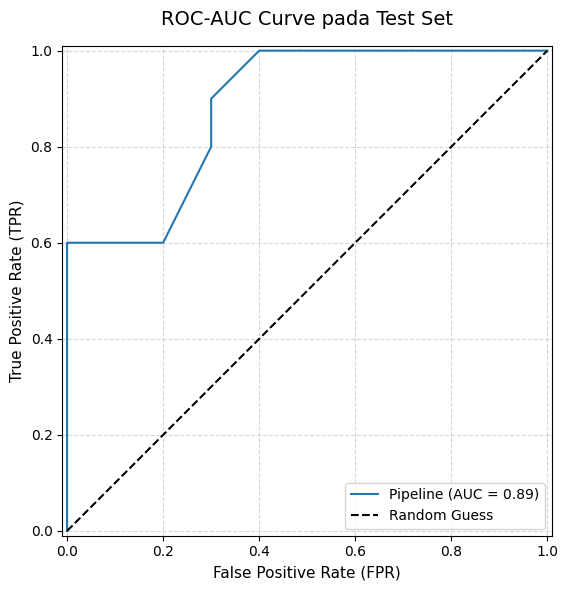

AUC Score: 0.8850


In [ ]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt

# Mendapatkan probabilitas prediksi untuk kelas positif (female = 1)
# Karena kNN di dalam pipeline mendukung predict_proba, kita bisa menggunakannya langsung
probabilities = best_estimator.predict_proba(X_test)[:, 1]

# Menghitung nilai AUC
auc = roc_auc_score(y_test, probabilities)

# Membuat plot ROC-AUC
plt.figure(figsize=(8, 6))
ax = plt.gca()

RocCurveDisplay.from_estimator(
    best_estimator,
    X_test,
    y_test,
    ax=ax
)

# Menambahkan garis bantu diagonal
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

plt.title("ROC-AUC Curve pada Test Set", fontsize=14, pad=15)
plt.xlabel("False Positive Rate (FPR)", fontsize=11)
plt.ylabel("True Positive Rate (TPR)", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"AUC Score: {auc:.4f}")